# Production-Ready Terrain Analysis at Scale: A Cloud-Native Geospatial Workflow with STAC and Xarray

_By Aycha Tammour_  

Working on a recent LiDAR course project, I needed to acquire Digital Elevation Model (DEM) data for an area in the Halifax region of Nova Scotia. The province provides excellent open data access through its [GeoNova portal](https://geonova.novascotia.ca), which includes high-quality DEM datasets.

However, the typical workflow involves downloading large raster files, mosaicking multiple tiles, and clipping them locally to an area of interest. While this approach works, it quickly becomes cumbersome and inefficient especially when working with high-resolution data.

As a data scientist, I tend to think in terms of processes rather than one-off tasks. Instead of manually downloading and managing data, the natural question becomes: how can this be turned into a scalable, reproducible workflow that allows me to query and analyze the data directly?

Modern geospatial workflows are increasingly shifting toward cloud-native approaches, where data is accessed and processed remotely rather than downloaded in bulk. In this tutorial, I demonstrate how to go from raw elevation data to terrain insights in a reproducible way without manually downloading a single file.

Specifically, this workflow shows how to:

- Query elevation data using STAC (via a Canadian DEM collection exposed through an Open Data Cube STAC API)
- Load data efficiently into Python using `odc.stac`, `xarray`, and `Dask`
- Derive terrain features such as slope, aspect, and hillshade using `xarray-spatial`
- Visualize results interactively with `hvplot` and `Plotly`

While the example focuses on DEM data, the same pattern applies broadly. I have used similar workflows with datasets like Sentinel-2 for geospatial machine learning tasks, where scalable feature extraction is essential.

## From Bulk Downloads to Cloud-Native Workflows

Working with DEMs (Digital Elevation Models) often involves a series of manual steps:

- Downloading large raster files and managing local storage
- Mosaicking or clipping multiple tiles to match an area of interest
- Building custom preprocessing workflows

These challenges are not unique to elevation data. Similar patterns appear when working with satellite imagery, where multiple bands and large file sizes introduce additional complexity.

Cloud-native approaches offer a different path. Using STAC and related tools, we can query only the data we need and load it directly into our analysis environment. Combined with lazy evaluation through Dask, this enables scalable workflows without the overhead of managing raw files locally.

I will follow up with a separate example using Sentinel-2 and Harmonized Landsat–Sentinel data, where this pattern is applied to time series feature extraction for a machine learning workflow.

**Tools used:**

| Library | Purpose |
|---|---|
| `pystac-client` | Query STAC APIs |
| `odc-stac` | Load STAC items into xarray |
| `dask` | Parallel computing and lazy evaluation |
| `xarray` | Labeled multi-dimensional arrays |
| `xarray-spatial` | Terrain derivatives (slope, hillshade) |
| `hvplot` | Interactive visualization |
| `plotly` | Interactive maps |


## Understanding STAC

[STAC (SpatioTemporal Asset Catalog)](https://stacspec.org/en/) is an open specification for describing geospatial data in a standardized way. It allows data providers to publish datasets with rich metadata, making it easy to discover and access geospatial assets. A STAC API is a web service implementing this specification, allowing users to query and retrieve metadata and assets from a catalog.

STAC organizes data into three levels:

- **Catalog**: top-level container for collections (or other catalogs)
- **Collection**: a group of related items (e.g. a DEM dataset)
- **Item**: a single geospatial asset (e.g. a raster tile) with its metadata

So, how do we get the data?


### Connect to the STAC Catalog

For this particular example, I want to use data from Canada's public STAC endpoint hosted by [geo.ca](https://www.geo.ca/). This endpoint provides access to a variety of geospatial datasets, including the Canadian Digital Elevation Model (CDEM). To connect to this STAC API, we can use the `pystac-client` library, which provides a convenient interface for querying STAC catalogs.

In [1]:
import pystac_client

STAC_ROOT = "https://datacube.services.geo.ca/stac/api"
catalog = pystac_client.Client.open(STAC_ROOT)


Let's inspect what datasets are available in this catalog:

In [2]:
import pandas as pd
pd.set_option("display.max_colwidth", None)

collections = catalog.collection_search().collection_list()
print(f"Number of collections in the catalog: {len(collections)}")

collections_df = pd.DataFrame(
    [
        {
            "id": c.id,
            "title": c.title,
            "description": (c.description or "")[:120],
            "license": c.license,
            "spatial_extent": (
                c.extent.to_dict().get("spatial", {}).get("bbox", [None])[0]
                if c.extent else None
            ),
            "temporal_extent": (
                c.extent.to_dict().get("temporal", {}).get("interval", [None])[0]
                if c.extent else None
            ),
        }
        for c in collections
    ]
)



Number of collections in the catalog: 46


Let's see if we can find the DEM dataset in this catalog. We can filter the collections based on keywords in their description or title to find relevant datasets. In this case, we are looking for collections that mention "DEM" (Digital Elevation Model).

In [3]:
collections_df[collections_df['description'].str.contains('DEM', case=False, na=False)]


,id,title,description,license,spatial_extent,temporal_extent
17,hrdem-arcticdem,Mosaic of High Resolution Digital Elevation Model for the Canadian Arctic region / Mosaïque de Modèle numérique d'élévation de haute résolution pour la région de l'Arctique Canadien,High-Resolution Digital Elevation Model (HRDEM) generated from optical stereo imagery. This data collection includes a D,OGL-Canada-2.0,"[-150.95787235250268, 53.425250098087716, -50.532847746518605, 85.14347264884341]","[2017-03-26T12:00:00Z, 2021-11-04T12:00:00Z]"
27,hrdem-mosaic-1m,Mosaic of High Resolution Digital Elevation Model (HRDEM) at 1m / Mosaïque de Modèle numérique d'élévation de haute résolution (MNEHR) à 1m,The High Resolution Digital Elevation Model (HRDEM) Mosaic represents the current and continous coverage of high-resolut,OGL-Canada-2.0,"[-150.95787235250268, 38.500123, -50.76054386118309, 73.975283]","[2018-08-10T12:00:00Z, 2024-11-09T12:00:00Z]"
29,hrdem-mosaic-2m,Mosaic of High Resolution Digital Elevation Model (HRDEM) at 2m / Mosaïque de Modèle numérique d'élévation de haute résolution (MNEHR) à 2m,The High Resolution Digital Elevation Model (HRDEM) Mosaic represents the current and continous coverage of high-resolut,OGL-Canada-2.0,"[-150.95787235250268, 38.500123, -50.532847746518605, 85.159132]","[2017-04-14T12:00:00Z, 2024-11-09T12:00:00Z]"
39,hrdem-lidar,Mosaic of High Resolution Digital Elevation Model (HRDEM) by LiDAR acquisition project / Mosaïque de Modèle numérique d'élévation de haute résolution (MNEHR) par project d'acquisition LiDAR,High-Resolution Digital Elevation Model (HRDEM) generated from LiDAR. This data collection includes a Digital Terrain Mo,OGL-Canada-2.0,"[-141.19215209619085, 41.2427923847184, -51.08012550640729, 69.57135820979204]","[2005-01-01T12:00:00Z, 2024-11-09T12:00:00Z]"
41,mrdem-30,Medium resolution digital elevation model - 30 meters (MRDEM-30) / Modèle numérique d'élévation à moyenne résolution - 30 mètres (MNEMR-30),Medium resolution digital elevation model - 30 meters (MRDEM-30). / Modèle numérique d'élévation à moyenne résolution -,OGL-Canada-2.0,"[-178.634083456441, 33.63960835766788, -8.498079497441832, 85.14750471001705]","[2024-06-13T12:00:00Z, 2026-01-21T12:00:00Z]"


Let’s consider a project that requires high-resolution elevation data for the Canadian Arctic. One option is the `hrdem-arcticdem` collection, which provides high-resolution Digital Surface Models (DSMs) derived from optical stereo imagery across the region between 2017 and 2021. The data is released under the [Open Government Licence – Canada](https://open.canada.ca/en/open-government-licence-canada)).


You can browse the collection here: [STAC Browser – hrdem-arcticdem](https://radiantearth.github.io/stac-browser/#/external/datacube.services.geo.ca/stac/api/collections/hrdem-arcticdem)


In [4]:
COLLECTION_ID = "hrdem-arcticdem"
collections_df[collections_df["id"] == COLLECTION_ID].T


,17
id,hrdem-arcticdem
title,Mosaic of High Resolution Digital Elevation Model for the Canadian Arctic region / Mosaïque de Modèle numérique d'élévation de haute résolution pour la région de l'Arctique Canadien
description,High-Resolution Digital Elevation Model (HRDEM) generated from optical stereo imagery. This data collection includes a D
license,OGL-Canada-2.0
spatial_extent,"[-150.95787235250268, 53.425250098087716, -50.532847746518605, 85.14347264884341]"
temporal_extent,"[2017-03-26T12:00:00Z, 2021-11-04T12:00:00Z]"


### Visualize Collection Extent

Before querying items, let's plot the spatial extent of the collection to get a better understanding of its coverage.
Please find the script to visualize the collection extent [here](https://github.com/astroAycha/canada-terrain-stac/blob/cb8ea1553e8a61cda5bdda7b1eece1b3c265c68f/dem_plots.py#L15)

In [5]:
from dem_plots import plot_collection_extent

plot_collection_extent(COLLECTION_ID, collections_df)


In [6]:
from IPython.display import IFrame
IFrame("hrdem-arcticdem_extent.html", width="100%", height=800)

### Query STAC Items

Now let's search the collection for all available items. Each item represents a single raster tile with its own metadata and asset links.

In [7]:
import odc.stac
import numpy as np
from shapely.geometry import shape

search = catalog.search(collections=COLLECTION_ID)
items = search.item_collection()
print(f"Found {len(items)} items in '{COLLECTION_ID}'")


Found 36 items in 'hrdem-arcticdem'


In [8]:
# Build a GeoDataFrame of item footprints
import geopandas as gpd

items_gdf = gpd.GeoDataFrame(
    {
        "item_id": [item.id for item in items],
        "datetime": [item.datetime for item in items],
    },
    geometry=[shape(item.geometry) for item in items],
    crs="EPSG:4326",
)


Let's visualize all item footprints on an interactive satellite map. We'll also highlight a specific area of interest (AOI) with a red bounding box. This AOI spans two tiles, which means if i am downloading the data manually, I would have to download both tiles (arcticdem-6_8 and arcticdem-7_8), mosaic them together and crop the AOI. Together this is over 250 GB of data. I will show that with this workflow, we can query and analyze the data without worrying about file management.

The script to create the plot below can be found [here](https://github.com/astroAycha/canada-terrain-stac/blob/cb8ea1553e8a61cda5bdda7b1eece1b3c265c68f/dem_plots.py#L70)

In [9]:
import geopandas as gpd
from shapely.geometry import box

# Define area of interest as [minx, miny, maxx, maxy]
EXTENT= [-78.926, 73.488, -78.475, 73.680]

bbox_gpd = gpd.GeoDataFrame([box(*EXTENT)], 
                            columns=["geometry"],
                            crs="EPSG:4326")

# project to EPSG:3979 NAD83 / Canada Atlas Lambert
area_km2 = bbox_gpd.to_crs(epsg=3979).area.iloc[0] / 1e6
print(f"AOI area: {area_km2:,.3f} km²")


AOI area: 295.540 km²


In [10]:
from dem_plots import plot_stac_boundaries

plot_stac_boundaries(
    items_gdf,
    collection_id=COLLECTION_ID,
    center_lat=73.6,
    center_lon=-78.7,
    zoom=6,
    bbox=EXTENT,
)


In [11]:
IFrame("hrdem-arcticdem_items_boundaries.html", width="100%", height=800)

## Loading Elevation Data with `odc.stac` and `Xarray`

We define an area of interest (AOI) and load elevation data directly into an Xarray Dataset using [Open Data Cube's `odc.stac`](https://github.com/opendatacube/odc-stac).

The `odc.stac.load` function reads data from STAC items and handles several complexities behind the scenes: accessing cloud-hosted assets, aligning them spatially based on metadata, and preparing them for parallel processing with Dask.

Rather than downloading files upfront, this approach uses lazy loading, i.e., data is only read when it is actually needed. This makes it possible to work interactively with large datasets without managing them locally.


### Lazy Loading: Working with Large Raster Data Efficiently

When using `odc.stac.load`, no computation happens immediately. Instead, the dataset is:

- **Chunked** into smaller blocks for parallel processing
- **Accessed on demand** from cloud storage
- **Evaluated only when required**, typically via `.compute()`

This model allows large raster datasets to be explored on a standard laptop.

For our relatively small AOI covering which spans two tiles from the ArcticDEM collection, the raw data volume can exceed 270 GB. While manageable in some environments, this quickly becomes a barrier when working across larger regions or iterating on multiple areas of interest.

With a lazy, cloud-native workflow, we avoid that overhead entirely. Only the subset of data required for a given operation is loaded into memory when `.compute()` is called, while Dask handles scheduling and execution efficiently in the background. This makes it practical to work with large DEMs even on a standard laptop.


In [54]:
search = catalog.search(
    collections=COLLECTION_ID,
    bbox=EXTENT
)

items = search.item_collection()

print(f"Found {len(items)} items in AOI: {EXTENT}")

Found 2 items in AOI: [-78.926, 73.488, -78.475, 73.68]


In [13]:
items[0].properties

{'created': '2024-03-26T13:51:36Z',
 'updated': '2025-11-25T19:19:04.433698Z',
 'datetime': '2021-05-16T12:00:00Z',
 'proj:epsg': 3979,
 'collection': 'hrdem-arcticdem',
 'proj:shape': [250000, 250000],
 'proj:geometry': {'type': 'Polygon',
  'coordinates': [[[500000.0, 2500000.0],
    [500000.0, 3000000.0],
    [0.0, 3000000.0],
    [0.0, 2500000.0],
    [500000.0, 2500000.0]]]},
 'proj:transform': [0.0, 2.0, 0.0, 3000000.0, 0.0, -2.0]}

In [14]:
items[0].assets.keys()

dict_keys(['dsm', 'extent', 'dsm-vrt', 'coverage', 'thumbnail'])

In [15]:
# Load the AOI data into an xarray dataset using odc.stac 

from odc.geo.geobox import GeoBox

proj_extent = bbox_gpd.to_crs(epsg=3979).geometry.total_bounds
print(f"Projected AOI bounds (EPSG:3979): {proj_extent}")

geobox = GeoBox.from_bbox(
    proj_extent,
    crs="EPSG:3979",
    resolution=5 # <- downsample to 5m resolution (original is 2m)
)


Projected AOI bounds (EPSG:3979): [ 491415.21847392 2730754.87342551  510314.82285658 2754711.24455041]


In [16]:
# Load the data with odc.stac.load, specifying the geobox and chunking for Dask
ds = odc.stac.load(
    items,
    bands=["dsm"], # <- specify the DSM layer only to avoid loading unnecessary data
    geobox=geobox,
    groupby="solar_day",
    chunks={"x": 1000, "y": 1000}, # <- adjust chunk size based on your system's memory and performance needs
)

ds


<xarray.Dataset> Size: 73MB
Dimensions:      (y: 4793, x: 3780, time: 1)
Coordinates:
  * y            (y) float64 38kB 2.755e+06 2.755e+06 ... 2.731e+06 2.731e+06
  * x            (x) float64 30kB 4.914e+05 4.914e+05 ... 5.103e+05 5.103e+05
  * time         (time) datetime64[us] 8B 2021-05-16T12:00:00
    spatial_ref  int32 4B 3979
Data variables:
    dsm          (time, y, x) float32 72MB dask.array<chunksize=(1, 1000, 1000), meta=np.ndarray>

In [17]:
import rioxarray
ds.rio.crs

CRS.from_wkt('PROJCS["NAD83(CSRS) / Canada Atlas Lambert",GEOGCS["NAD83(CSRS)",DATUM["NAD83_Canadian_Spatial_Reference_System",SPHEROID["GRS 1980",6378137,298.257222101]],PRIMEM["Greenwich",0],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AUTHORITY["EPSG","4617"]],PROJECTION["Lambert_Conformal_Conic_2SP"],PARAMETER["latitude_of_origin",49],PARAMETER["central_meridian",-95],PARAMETER["standard_parallel_1",49],PARAMETER["standard_parallel_2",77],PARAMETER["false_easting",0],PARAMETER["false_northing",0],UNIT["metre",1],AXIS["Easting",EAST],AXIS["Northing",NORTH],AUTHORITY["EPSG","3979"]]')

This dataset has dimensions `(time, y, x)` and includes a **`dsm`** (Digital Surface Model) which represents surface elevation and captures features such as vegetation, ice, and buildings.

Other Canadian DEM collections, such as the  [Medium resolution digital elevation model - 30 meters (MRDEM-30)](https://radiantearth.github.io/stac-browser/#/external/datacube.services.geo.ca/stac/api/collections/mrdem-30), may also provide a Digital Terrain Model (DTM) representing bare-earth elevation. This can be used to derive additional products like a Canopy Height Model (CHM). Some collections may also include precomputed terrain derivatives such as hillshade. We will explore an example of computing a CHM later in this article.

All data variables are backed by Dask arrays and are not computed until explicitly triggered.

### Extract and Inspect Elevation

This particular dataset has only one time step so we don't have to worry about this here, but for other datasets you may find that there are multiple time steps. In such cases, you may depending on your application select one of the time steps (e.g., the first one) or choose to compute an aggregate (e.g., mean or median) across time before triggering computation to bring the elevation data into memory.

In [24]:
%%time
# This step loads the DSM data into memory
elevation = ds.dsm.mean(dim="time", skipna=True).compute()

CPU times: total: 27 s
Wall time: 10.1 s


Let's take a look at the elevation data we just loaded:

In [19]:
import numpy as np

print("Type:", type(elevation))
print("Dims:", elevation.dims)
print("Shape:", elevation.shape)
print("Dtype:", elevation.dtype)
print("CRS:", getattr(elevation, "rio", None).crs if hasattr(elevation, "rio") else "N/A")

nulls = int(elevation.isnull().sum().item())
valid = int(elevation.size - nulls)
print("Null cells:", f"{nulls:,}")
print("Valid cells:", f"{valid:,}")

print("Min:", float(elevation.min(skipna=True).item()))
print("Max:", float(elevation.max(skipna=True).item()))
print("Mean:", float(elevation.mean(skipna=True).item()))
print("Std:", float(elevation.std(skipna=True).item()))

print("Memory (MB):", round(elevation.nbytes / (1024**2), 2))

Type: <class 'xarray.core.dataarray.DataArray'>
Dims: ('y', 'x')
Shape: (4793, 3780)
Dtype: float32
CRS: EPSG:3979
Null cells: 911,239
Valid cells: 17,206,301
Min: -0.772672176361084
Max: 1147.308349609375
Mean: 184.20950317382812
Std: 160.2916259765625
Memory (MB): 69.11


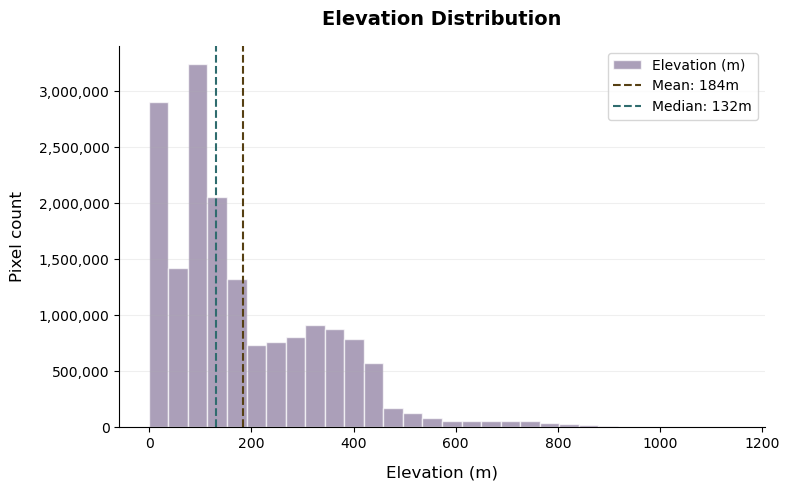

In [53]:
import pandas as pd
import matplotlib.pyplot as plt

elev_series = pd.Series(
    elevation.values.ravel(),
    name="Elevation (m)"
).dropna()

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np

fig, ax = plt.subplots(figsize=(8, 5))

# Plot histogram
elev_series.plot.hist(
    bins=30,
    ax=ax,
    color="#88769C",
    edgecolor="w",
    linewidth=1,
    alpha=0.7,
)

# Add a vertical line for mean and median
mean_elev = float(elev_series.mean())
median_elev = float(elev_series.median())
ax.axvline(mean_elev,   color="#564013", linestyle="--", linewidth=1.5, label=f"Mean: {mean_elev:.0f}m")
ax.axvline(median_elev, color="#2F6C6E", linestyle="--",  linewidth=1.5, label=f"Median: {median_elev:.0f}m")

# Styling
ax.set_xlabel("Elevation (m)", fontsize=12, labelpad=10)
ax.set_ylabel("Pixel count", fontsize=12, labelpad=10)
ax.set_title("Elevation Distribution", fontsize=14, fontweight="bold", pad=15)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{int(x):,}"))
ax.spines[["top", "right"]].set_visible(False)
ax.legend(fontsize=10)
ax.grid(axis="y", linestyle="-", alpha=0.2)

plt.tight_layout()
plt.show()


## Deriving Terrain Features (Slope, Hillshade, and More)

In [21]:
from xrspatial import slope, aspect, hillshade

slope = slope(elevation)
aspect = aspect(elevation)
hillshade = hillshade(elevation)

If you need to save the elevation data (or any derived products) to a file, you can do so using `rasterio` or `xarray`'s built-in I/O capabilities. For example, to save the elevation data as a Cloud Optimized GeoTIFF (COG), you can use the following code:

In [22]:
elevation.rio.write_crs("EPSG:3979").rio.to_raster(
    "elevation_cog.tif",
    driver="COG",
    compress="deflate",
)

## Visualizing Terrain Data
Let's now visualize the elevation data and the other terrain derivatives we just computed. We can use `hvplot` for interactive visualization directly from the `xarray` Dataset. This allows us to explore the data without needing to export it to a file first.

In [25]:
import hvplot.xarray

# Downsample hillshade for faster plotting (optional)
hillshade_coarse = hillshade.coarsen(x=2, y=2, boundary="trim").mean()

aspect_plot = aspect.hvplot.image(geo=True,
                    tiles="ESRI",
                    alpha=0.8,
                    cmap= "twilight",
                    title='Aspect (degrees)',
                    frame_width=500,
                    frame_height=500) 


hillshade_plot = hillshade_coarse.hvplot.image(geo=True,
                    tiles="ESRI",
                    alpha=0.6,
                    cmap= "gray",
                    title='Hillshade',
                    frame_width=500,
                    frame_height=500)

shaded_relief = aspect_plot * hillshade_plot
shaded_relief.opts(title="Shaded Relief (Aspect x Hillshade)")


hvplot.save(shaded_relief, "shaded_relief.html")
IFrame("shaded_relief.html", width="100%", height=600)

# Another Example: Canopy Height Model (CHM)

If we have both the DSM and DTM bands available, we can compute the Canopy Height Model (CHM) by simply subtracting the DTM from the DSM. This gives us the height of vegetation and structures above the ground level. The CHM can be useful for various applications, such as forestry, urban planning, and habitat analysis.

I put together a [script](https://github.com/astroAycha/canada-terrain-stac/blob/cb8ea1553e8a61cda5bdda7b1eece1b3c265c68f/get_dem.py#L8) `get_dem` that encapsulates the entire workflow of querying the STAC API, loading the data, and computing terrain derivatives. This function takes parameters for the collection name, bounding box, coordinate reference system, resolution, bands to load, and an optional date range. It returns the elevation data along with derived products like slope, aspect, hillshade, and canopy height model (if both DSM and DTM are available). Feel free to check it out and use it as a starting point for your own projects!

Let's check out the CHM values for an AOI in Quebec south of Mont Albert:

In [ ]:
%%time
from get_dem import get_dem

qu_extent = [-66.2695, 48.327, -65.3796, 48.6402]

qu_elevation, qu_slope, qu_aspect, qu_hillshade, qu_chm = get_dem(collection="mrdem-30",
                                                bbox=qu_extent,
                                                crs="EPSG:3979",
                                                daterange=None,
                                                bands=['dsm', 'dtm'],
                                                resolution=30)

Found 1 items in AOI: [-66.2695, 48.327, -65.3796, 48.6402]
AOI area: 2,300.44 km²
Projected AOI bounds (EPSG:3979): [2048978.98811277  399347.57777938 2123536.28274374  459825.38488365]
CPU times: total: 7.14 s
Wall time: 5.5 s


Let's look at the CHM:

In [ ]:
chm_plot = qu_chm.hvplot.image(geo=True,
                                tiles="ESRI",
                                alpha=0.8,
                                cmap= "GnBu",
                                title='Canopy Height Model (m)',
                                frame_width=600,
                                frame_height=600)

hvplot.save(chm_plot, "qu_chm.html")
IFrame("qu_chm.html", width="100%", height=600)

# Summary

This workflow demonstrates that working with large geospatial datasets does not require downloading them. By combining STAC, ODC, and Xarray, we queried, loaded, and processed over 270GB of elevation data while transferring only the pixels we actually needed  -a fundamental shift in how geospatial data can be handled.

At the core of this approach is the principle of **compute-near-data**: Rather than downloading and preprocessing locally, computation is performed as close to the data source as possible. This reduces data transfer, simplifies preprocessing, and enables efficient use of cloud-based resources (an approach often referred to as cloud-native computing).

The result is a workflow that is:

- **Scalable**: Dask handles datasets that do not fit in memory
- **Reproducible**: the entire workflow runs from a bounding box and a collection name
- **Cloud-native**: no local storage, no manual tile management

The terrain derivatives we computed (slope, hillshade, aspect) are more than visualizations. They are widely used in GIS, remote sensing, and environmental analysis, and increasingly serve as features in geospatial machine learning models, from land cover classification and flood risk prediction to habitat mapping. 

This pattern extends beyond DEMs. The same approach can be applied to other STAC-enabled datasets, such as Sentinel-2 or Landsat, enabling scalable feature engineering for broader geospatial ML workflows. An example of this in practice can be found in a [recent project](https://github.com/astroAycha/geospatial_mlops) in which I derive time series data from Sentinel-2 and Harmonized Landsat–Sentinel data for a machine learning workflow. This will be the focus of a future post, where I will explore how to integrate these features into machine learning pipelines using similar cloud-native approaches.



# Useful Links

- [pystac-client documentation](https://pystac-client.readthedocs.io/)
- [odc-stac documentation](https://odc-stac.readthedocs.io/)
- [xarray-spatial documentation](https://xarray-spatial.org/)
- [geo.ca STAC catalog](https://datacube.services.geo.ca/stac/api)
- [hrdem-arcticdem collection](https://radiantearth.github.io/stac-browser/#/external/datacube.services.geo.ca/stac/api/collections/hrdem-arcticdem)
- [mrdem-30 collection](https://radiantearth.github.io/stac-browser/#/external/datacube.services.geo.ca/stac/api/collections/mrdem-30)


In [26]:
from datetime import datetime
from IPython.display import Markdown
Markdown(f"*Last updated: {datetime.now().strftime('%B %d, %Y')}*")

*Last updated: May 04, 2026*